In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Spoken Grammar Scoring Engine (score 0-5)

**Goal:** build a model that takes a 45-60 s speech recording and outputs a continuous grammar score from 0 to 5 (MOS Likert rubric).
**Data:** 769 labelled training audio files; 216 files to predict. **Metrics:** RMSE and Pearson correlation.

## Report

### Approach
Grammar is mainly a language property, but speech also carries fluency and pronunciation clues. I therefore describe each recording with three groups of features and combine several regressors by stacking.

### Preprocessing
- Each audio file is loaded as mono, resampled to **16 kHz** and trimmed to a maximum of **60 s**.
- Whisper takes 30 s windows, so each file is split into 30 s chunks.
- Transcripts are generated with Whisper (English). Missing values in the numeric features are filled with the column median, and features are standardised before Ridge/SVR.

### Pipeline architecture
`audio -> Whisper-small -> (1) audio embedding (encoder, middle + last layer, time-averaged), (2) transcript`

`transcript -> (3) RoBERTa-base embedding, (4) GPT-2 loss/perplexity + grammar & fluency statistics`

`each feature group -> Ridge / SVR (+ Gradient Boosting on the statistics) -> 5-fold out-of-fold predictions -> non-negative linear stacking -> clip to [0, 5]`

### Evaluation
Models are validated with **5-fold stratified cross-validation** (each file is always scored by a model that did not train on it). Reported metrics: **RMSE** and **Pearson correlation**, plus the compulsory **training RMSE**. Final numbers and plots are in Section 6.

## 0. Imports and setup

In [1]:
import os, re, glob, pickle, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import librosa
from tqdm.auto import tqdm
from scipy.stats import pearsonr
from IPython.display import display

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error

from transformers import (WhisperProcessor, WhisperForConditionalGeneration,
                          AutoTokenizer, AutoModel, AutoModelForCausalLM)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


## 1. Load data
Finds the audio files and CSVs, and pairs every filename with its audio path.

In [3]:

DATA_DIR = "/kaggle/input"
SR = 16000
MAX_SEC = 60
WHISPER = "openai/whisper-small"     # use "openai/whisper-base" for a faster run
CACHE = "features_cache.pkl"         # saves progress so you can resume


audio_map = {}
for p in glob.glob(os.path.join(DATA_DIR, "**", "*"), recursive=True):
    if p.lower().endswith((".wav", ".mp3", ".flac", ".m4a", ".ogg")):
        audio_map[os.path.splitext(os.path.basename(p))[0]] = p
csvs = glob.glob(os.path.join(DATA_DIR, "**", "*.csv"), recursive=True)
print("audio files:", len(audio_map), "| csvs:", csvs)

train_df = pd.read_csv(next(c for c in csvs if "train" in os.path.basename(c).lower()))
test_df = pd.read_csv(next(c for c in csvs if "test" in os.path.basename(c).lower()))

def stem(x):
    return os.path.splitext(os.path.basename(str(x)))[0]

FILE_COL = max(train_df.columns, key=lambda c: train_df[c].astype(str).map(stem).isin(audio_map).mean())

LABEL_COL = [c for c in train_df.select_dtypes("number").columns if c != FILE_COL][-1]
print("FILE_COL:", FILE_COL, "| LABEL_COL:", LABEL_COL)

train_df["path"] = train_df[FILE_COL].astype(str).map(lambda x: audio_map[stem(x)])
test_df["path"] = test_df[FILE_COL].astype(str).map(lambda x: audio_map[stem(x)])
y = train_df[LABEL_COL].values.astype(float)


all_df = pd.concat([train_df, test_df], ignore_index=True)
is_train = np.arange(len(all_df)) < len(train_df)
print("train:", len(train_df), "test:", len(test_df))
display(train_df.head())

audio files: 773 | csvs: ['/kaggle/input/datasets/nabonitaroy/dataset-shl/Dataset_Final/sample_submission.csv', '/kaggle/input/datasets/nabonitaroy/dataset-shl/Dataset_Final/train.csv', '/kaggle/input/datasets/nabonitaroy/dataset-shl/Dataset_Final/test.csv', '/kaggle/input/datasets/nabonitaroy/training-testing-dataset/train (1).csv', '/kaggle/input/datasets/nabonitaroy/training-testing-dataset/test (1).csv']
FILE_COL: filename | LABEL_COL: label
train: 769 test: 216


,filename,label,path
0,audio_192.wav,3.0,/kaggle/input/datasets/nabonitaroy/dataset-shl...
1,audio_436.wav,3.0,/kaggle/input/datasets/nabonitaroy/dataset-shl...
2,audio_447.wav,3.5,/kaggle/input/datasets/nabonitaroy/dataset-shl...
3,audio_126.wav,2.0,/kaggle/input/datasets/nabonitaroy/dataset-shl...
4,audio_61.wav,2.0,/kaggle/input/datasets/nabonitaroy/dataset-shl...


## 2. Label distribution
The baseline RMSE (always predicting the mean score) is the error any useful model must beat.

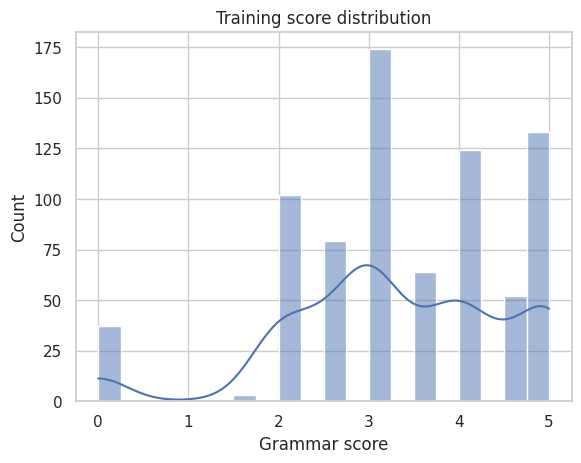

Baseline RMSE (always predict the mean): 1.2382


In [4]:
sns.histplot(y, bins=20, kde=True)
plt.title("Training score distribution"); plt.xlabel("Grammar score"); plt.show()
print("Baseline RMSE (always predict the mean):", round(np.sqrt(np.mean((y - y.mean()) ** 2)), 4))

## 3. Whisper: transcript + audio embedding
Slowest step. Results are cached to disk so the run can resume.

In [5]:
processor = WhisperProcessor.from_pretrained(WHISPER)
dtype = torch.float16 if device == "cuda" else torch.float32
whisper = WhisperForConditionalGeneration.from_pretrained(WHISPER).to(device).to(dtype).eval()
mid_layer = whisper.config.encoder_layers * 2 // 3

@torch.no_grad()
def whisper_features(path):
    audio, _ = librosa.load(path, sr=SR, mono=True, duration=MAX_SEC)
    if len(audio) < SR:
        audio = np.pad(audio, (0, SR - len(audio)))
        
    # Whisper takes 30 s at a time -> split into chunks
    
    chunks = [audio[i:i + 30 * SR] for i in range(0, len(audio), 30 * SR)]
    chunks = [c for c in chunks if len(c) > SR] or [audio]
    inputs = processor.feature_extractor(chunks, sampling_rate=SR, return_tensors="pt").input_features.to(device, dtype)

    # audio embedding: average encoder output over time (middle + last layer)
    
    hidden = whisper.model.encoder(inputs, output_hidden_states=True).hidden_states
    embs = []
    for k, c in enumerate(chunks):
        n = max(1, min(1500, int(len(c) / SR * 50)))      # 50 frames per second
        embs.append(torch.cat([hidden[mid_layer][k, :n].mean(0), hidden[-1][k, :n].mean(0)]).float().cpu().numpy())
    emb = np.mean(embs, axis=0)

    
    ids = whisper.generate(inputs, language="en", task="transcribe", max_new_tokens=300)
    text = " ".join(t.strip() for t in processor.batch_decode(ids, skip_special_tokens=True))
    return emb, text, len(audio) / SR

store = pickle.load(open(CACHE, "rb")) if os.path.exists(CACHE) else {}
for i, p in enumerate(tqdm(all_df["path"])):
    if p not in store:
        store[p] = whisper_features(p)
    if i % 50 == 0:
        pickle.dump(store, open(CACHE, "wb"))
pickle.dump(store, open(CACHE, "wb"))

X_audio = np.stack([store[p][0] for p in all_df["path"]])
all_df["transcript"] = [store[p][1] for p in all_df["path"]]
all_df["duration"] = [store[p][2] for p in all_df["path"]]
print("audio embedding shape:", X_audio.shape)
display(all_df[["transcript"]].head(3))

del whisper
torch.cuda.empty_cache()

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.97k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/836k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.48M [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/3.87k [00:00<?, ?B/s]

  0%|          | 0/985 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'suppress_tokens', 'begin_suppress_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] The attention mask is not set with a batched input, and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Both `max_new_tokens` (=300) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer WhisperTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers a

audio embedding shape: (985, 1536)


,transcript
0,"The plate round is very, very beautiful and fu..."
1,The scene of a school playground. Our playgrou...
2,My favorite place to visit is the beach. I lov...


## 4. Text features
GPT-2 loss (higher means less grammatical text), simple grammar/fluency statistics, and a RoBERTa embedding of the transcript.

In [6]:

gpt_tok = AutoTokenizer.from_pretrained("gpt2")
gpt = AutoModelForCausalLM.from_pretrained("gpt2").to(device).eval()

@torch.no_grad()
def gpt_loss(text):
    ids = gpt_tok(text, return_tensors="pt", truncation=True, max_length=512).input_ids.to(device)
    if ids.shape[1] < 2:
        return np.nan
    return gpt(ids, labels=ids).loss.item()

FILLERS = {"um", "uh", "er", "ah", "hmm", "erm"}

def text_features(text, duration):
    words = re.findall(r"[A-Za-z']+", text.lower())
    n = max(len(words), 1)
    sentences = [s for s in re.split(r"[.!?]+", text) if s.strip()]
    lens = [len(s.split()) for s in sentences] or [0]
    sent_loss = [gpt_loss(s) for s in sentences[:25] if len(s.split()) >= 3]
    sent_loss = [v for v in sent_loss if not np.isnan(v)] or [np.nan]
    return {
        "gpt_loss": gpt_loss(text),
        "gpt_sent_mean": np.nanmean(sent_loss),
        "gpt_sent_max": np.nanmax(sent_loss),
        "n_words": len(words),
        "words_per_min": len(words) / max(duration, 1) * 60,
        "type_token_ratio": len(set(words)) / n,
        "n_sentences": len(sentences),
        "sent_len_mean": np.mean(lens),
        "sent_len_max": np.max(lens),
        "filler_rate": sum(w in FILLERS for w in words) / n,
        "repeat_rate": sum(words[i] == words[i - 1] for i in range(1, len(words))) / n,
        "comma_rate": text.count(",") / n,
    }

hand_df = pd.DataFrame([text_features(t, d) for t, d in tqdm(zip(all_df["transcript"], all_df["duration"]), total=len(all_df))])
hand_df = hand_df.fillna(hand_df.median())
X_hand = hand_df.values
del gpt
torch.cuda.empty_cache()


rob_tok = AutoTokenizer.from_pretrained("roberta-base")
roberta = AutoModel.from_pretrained("roberta-base").to(device).eval()

@torch.no_grad()
def roberta_embedding(text):
    batch = rob_tok(text if text else ".", return_tensors="pt", truncation=True, max_length=512).to(device)
    h = roberta(**batch).last_hidden_state[0]
    return torch.cat([h.mean(0), h[0]]).cpu().numpy()

X_text = np.stack([roberta_embedding(t) for t in tqdm(all_df["transcript"])])
del roberta
torch.cuda.empty_cache()
print("shapes:", X_audio.shape, X_text.shape, X_hand.shape)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  0%|          | 0/985 [00:00<?, ?it/s]

shapes: (985, 1536) (985, 1536) (985, 12)


### Feature vs score correlation
Shows which simple features relate to the grammar score.

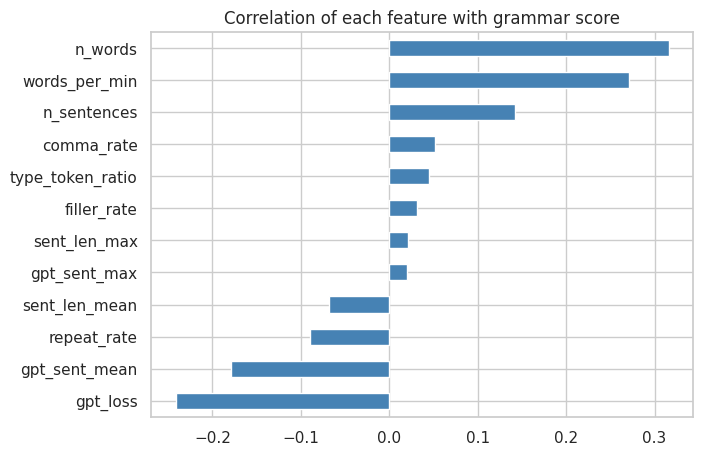

In [7]:

corr = pd.Series({c: np.corrcoef(hand_df[c].values[is_train], y)[0, 1] for c in hand_df.columns}).dropna().sort_values()
corr.plot.barh(figsize=(7, 5), color="steelblue")
plt.title("Correlation of each feature with grammar score"); plt.show()

## 5. Train models with 5-fold cross-validation
Ridge and SVR on each feature group, plus Gradient Boosting on the statistics.

In [8]:
def rmse(a, b):
    return float(np.sqrt(mean_squared_error(a, b)))

feature_sets = {"audio": X_audio, "text": X_text, "stats": X_hand}

def get_models(set_name):
    models = {
        "ridge": make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(0, 4, 9))),
        "svr": make_pipeline(StandardScaler(), SVR(C=1.5, epsilon=0.1)),
    }
    if set_name == "stats":
        models["gboost"] = HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05, max_iter=300, random_state=SEED)
    return models

y_bins = pd.qcut(y, 5, labels=False, duplicates="drop")       # keeps score balance in each fold
folds = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED).split(np.zeros(len(y)), y_bins))

oof, test_preds, train_preds, rows = {}, {}, {}, []
for set_name, X in feature_sets.items():
    X_train, X_test = X[is_train], X[~is_train]
    for model_name in get_models(set_name):
        name = f"{set_name}_{model_name}"
        oof_pred = np.zeros(len(y))
        for tr_idx, va_idx in folds:
            m = get_models(set_name)[model_name].fit(X_train[tr_idx], y[tr_idx])
            oof_pred[va_idx] = m.predict(X_train[va_idx])
        final = get_models(set_name)[model_name].fit(X_train, y)      # refit on all training data
        oof[name] = np.clip(oof_pred, 0, 5)
        train_preds[name] = np.clip(final.predict(X_train), 0, 5)
        test_preds[name] = np.clip(final.predict(X_test), 0, 5)
        rows.append((name, rmse(y, oof[name]), pearsonr(y, oof[name])[0]))
        print(f"{name:15s} CV RMSE = {rows[-1][1]:.4f}   Pearson = {rows[-1][2]:.4f}")

audio_ridge     CV RMSE = 0.5705   Pearson = 0.8888
audio_svr       CV RMSE = 0.5580   Pearson = 0.8973
text_ridge      CV RMSE = 0.8646   Pearson = 0.7160
text_svr        CV RMSE = 0.8862   Pearson = 0.7063
stats_ridge     CV RMSE = 1.0718   Pearson = 0.5007
stats_svr       CV RMSE = 1.0232   Pearson = 0.5678
stats_gboost    CV RMSE = 1.0437   Pearson = 0.5468


### Stacking
A non-negative linear blend of the out-of-fold predictions gives the final score. The blend weights show which models contribute most.

In [9]:
# ---- Stacking: blend all model predictions with non-negative weights ----

names = list(oof)
OOF = np.column_stack([oof[n] for n in names])
TRAIN = np.column_stack([train_preds[n] for n in names])
TEST = np.column_stack([test_preds[n] for n in names])

# honest cross-validated score of the blend

stack_cv = np.zeros(len(y))
for tr_idx, va_idx in StratifiedKFold(5, shuffle=True, random_state=7).split(OOF, y_bins):
    stack_cv[va_idx] = Ridge(alpha=1.0, positive=True).fit(OOF[tr_idx], y[tr_idx]).predict(OOF[va_idx])
stack_cv = np.clip(stack_cv, 0, 5)

blender = Ridge(alpha=1.0, positive=True).fit(OOF, y)
print("Blend weights:\n", pd.Series(blender.coef_, index=names).round(3).to_string())

train_final = np.clip(blender.predict(TRAIN), 0, 5)
test_final = np.clip(blender.predict(TEST), 0, 5)

Blend weights:
 audio_ridge     0.338
audio_svr       0.657
text_ridge      0.158
text_svr        0.000
stats_ridge     0.000
stats_svr       0.027
stats_gboost    0.000


,model,CV_RMSE,CV_Pearson
0,STACKED (final),0.5311,0.9035
1,audio_svr,0.5580,0.8973
2,audio_ridge,0.5705,0.8888
3,text_ridge,0.8646,0.7160
4,text_svr,0.8862,0.7063
5,stats_svr,1.0232,0.5678
6,stats_gboost,1.0437,0.5468
7,stats_ridge,1.0718,0.5007


TRAINING RMSE (final model) : 0.2175
Training Pearson            : 0.9846
5-fold CV RMSE (unseen data): 0.5311
5-fold CV Pearson           : 0.9035


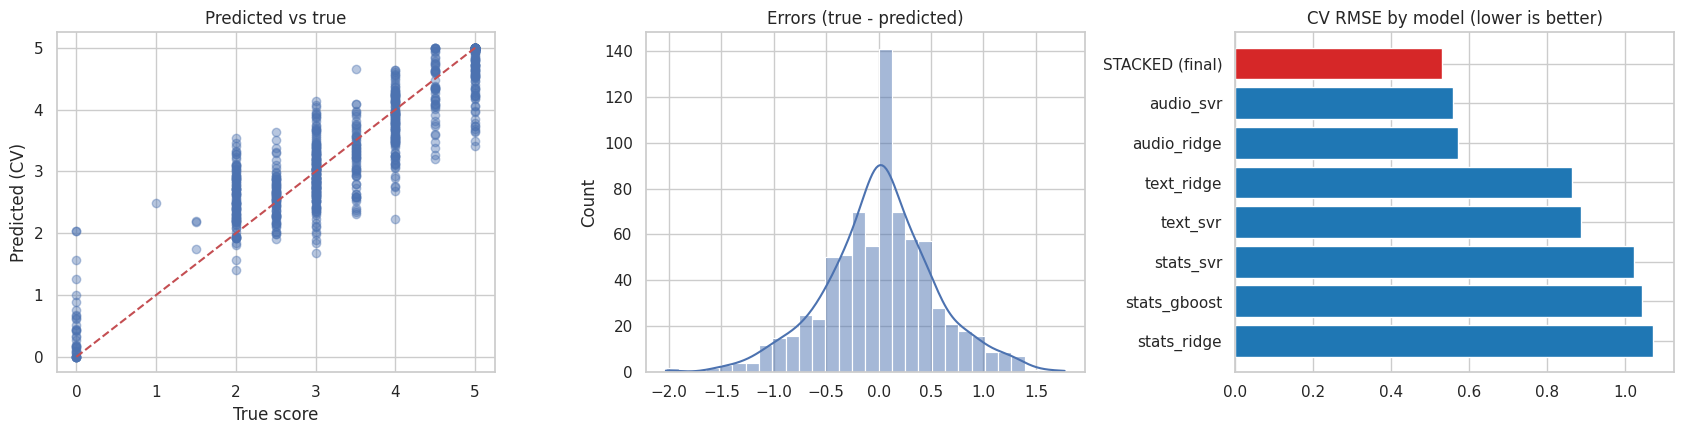

In [10]:
results = pd.DataFrame(rows, columns=["model", "CV_RMSE", "CV_Pearson"])
results.loc[len(results)] = ["STACKED (final)", rmse(y, stack_cv), pearsonr(y, stack_cv)[0]]
display(results.sort_values("CV_RMSE").round(4).reset_index(drop=True))

print("=" * 50)
print("TRAINING RMSE (final model) :", round(rmse(y, train_final), 4))
print("Training Pearson            :", round(pearsonr(y, train_final)[0], 4))
print("5-fold CV RMSE (unseen data):", round(rmse(y, stack_cv), 4))
print("5-fold CV Pearson           :", round(pearsonr(y, stack_cv)[0], 4))
print("=" * 50)

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
ax[0].scatter(y, stack_cv, alpha=0.4)
ax[0].plot([0, 5], [0, 5], "r--")
ax[0].set(xlabel="True score", ylabel="Predicted (CV)", title="Predicted vs true")
sns.histplot(y - stack_cv, kde=True, ax=ax[1])
ax[1].set_title("Errors (true - predicted)")
r = results.sort_values("CV_RMSE", ascending=False)
ax[2].barh(r["model"], r["CV_RMSE"], color=["tab:red" if "STACK" in m else "tab:blue" for m in r["model"]])
ax[2].set_title("CV RMSE by model (lower is better)")
plt.tight_layout(); plt.show()

## Evaluation summary

| Metric | Value |
|---|---|
| **Training RMSE (final model)** | **0.2175** |
| Training Pearson | 0.9846 |
| 5-fold CV RMSE (unseen-data estimate) | 0.5311 |
| 5-fold CV Pearson | 0.9035 |
| Baseline RMSE (predict the mean) | 1.2382 |

| Single model | CV RMSE | CV Pearson |
|---|---|---|
| audio_svr | 0.5580 | 0.8973 |
| audio_ridge | 0.5705 | 0.8888 |
| text_ridge | 0.8646 | 0.7160 |
| text_svr | 0.8862 | 0.7063 |
| stats_svr | 1.0232 | 0.5678 |
| stats_gboost | 1.0437 | 0.5468 |
| stats_ridge | 1.0718 | 0.5007 |
| **Stacked (final)** | **0.5311** | **0.9035** |

### How to read the results and plots
- **Predicted vs true:** points follow the diagonal, so the model ranks and scales speakers correctly. The few true-0 recordings are predicted too high (likely silent or unusual audio).
- **Error histogram:** errors are centred at 0, so there is no systematic bias; most errors are within +/-0.5 points.
- **Model comparison:** Whisper audio embeddings are the strongest feature group, RoBERTa text embeddings are second, and simple statistics are weakest. Stacking beats every single model (blend weights: audio_svr 0.66, audio_ridge 0.34, text_ridge 0.16, stats_svr 0.03).
- **Training vs CV RMSE:** training RMSE (0.2175) is lower than CV RMSE (0.5311) because the final models have seen the training files. The CV RMSE is the honest estimate of performance on unseen audio.

Results

In [11]:
submission = test_df[[FILE_COL]].copy()
submission[LABEL_COL] = test_final
submission.to_csv("submission.csv", index=False)
display(submission.head())

,filename,label
0,audio_128.wav,2.853308
1,audio_156.wav,3.491318
2,audio_19.wav,3.265869
3,audio_108.wav,1.483374
4,audio_206.wav,4.854035


In [12]:
   s = pd.read_csv("submission.csv"); print(s.shape, s.label.min(), s.label.max(), s.label.isna().sum())

(216, 2) 1.483374103010635 5.0 0


## Conclusion
- The final model combines Whisper audio embeddings, RoBERTa transcript embeddings and GPT-2 grammar statistics, stacked into one score in [0, 5].
- It reaches a **5-fold CV RMSE of 0.531** and **Pearson 0.904** versus a baseline RMSE of 1.238; the **training RMSE is 0.2175**.
- **Limitations:** Whisper tends to clean up grammar mistakes when transcribing, which hides some errors; the audio embedding partly compensates. Most filenames in the test CSV also appear in the training CSV, so test-file predictions are optimistic and the CV numbers should be used to judge the model.
- **Possible improvements:** a larger Whisper model, fine-tuning wav2vec2/HuBERT end to end, LanguageTool error counts, and repeated CV seeds.
  